# DMIF — Per-Company Accuracy Profiling (v2)
Breaks down the FUSION model's accuracy company-by-company. Answers: which CSE stocks does DMIF predict well, and which does it struggle with?

**v2 fix:** ranks companies by F1-score and reports Balanced Accuracy instead of raw accuracy. Raw accuracy is misleading here — a company with 85% DOWN days can score high accuracy just by always predicting DOWN, with zero real skill (F1=0). Balanced accuracy and F1 correct for this.

Output feeds directly into the web app's `company_accuracy_stats` Postgres table.

# Keep-alive

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install and Imports

In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


# Configuration

In [ ]:
MODELS_DIR   = '/content/drive/MyDrive/DMIF/models'
LSTM_PATH    = f'{MODELS_DIR}/lstm_bilstm.keras'
CNN_PATH     = f'{MODELS_DIR}/cnn_mobilenet_candlestick.keras'
BUNDLE_PATH  = f'{MODELS_DIR}/fusion_bundle.pkl'

CSV_PATH     = '/content/drive/MyDrive/DMIF/master_dataset_clean_80.csv'
LOCAL_CSV    = '/content/master_dataset.csv'
INDEX_PATH   = '/content/drive/MyDrive/DMIF/chart_index_final.csv'

ZIP_PATH     = '/content/drive/MyDrive/DMIF/candlestick_images.zip'
LOCAL_ZIP    = '/content/candlestick_images.zip'
LOCAL_CHARTS = '/content/charts_local'

SEQ_LEN      = 30
IMG_SIZE     = 64
CHART_TYPE   = 'candlestick'

LSTM_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Log_Volume',
    'Daily_Return', 'Log_Return', 'HL_Range', 'OC_Range',
    'MA_24', 'MA_30', 'MA_500',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Middle', 'BB_Width',
    'Volatility_10', 'SAR', 'SAR_Trend',
    'Fib_0236', 'Fib_0382', 'Fib_05', 'Fib_0618', 'Fib_0786',
    'Volume_MA_10', 'Volume_Ratio'
]

MIN_TEST_SAMPLES = 20  # skip companies with too few test-set samples for a meaningful stat

print(f"LSTM   : {LSTM_PATH}")
print(f"CNN    : {CNN_PATH}")
print(f"Bundle : {BUNDLE_PATH}")

LSTM   : /content/drive/MyDrive/DMIF/models/lstm_bilstm.keras
CNN    : /content/drive/MyDrive/DMIF/models/cnn_mobilenet_candlestick.keras
Bundle : /content/drive/MyDrive/DMIF/models/fusion_bundle.pkl


# Load Models and Fusion Bundle

In [ ]:
print("Loading BiLSTM...")
lstm_model = load_model(LSTM_PATH)

print("Loading MobileNetV2 (candlestick)...")
cnn_model = load_model(CNN_PATH)

print("Loading fusion bundle...")
with open(BUNDLE_PATH, 'rb') as f:
    bundle = pickle.load(f)

fusion_clf     = bundle['fusion_clf']
best_threshold = bundle['best_threshold']

print("All loaded")
print(f"Fusion threshold: {best_threshold:.2f}")

Loading BiLSTM...
Loading MobileNetV2 (candlestick)...
Loading fusion bundle...
All loaded
Fusion threshold: 0.35


# Rebuild LSTM Sequences (with company + date kept)

In [ ]:
import shutil

print("Copying CSV to local disk...")
shutil.copy(CSV_PATH, LOCAL_CSV)

df = pd.read_csv(LOCAL_CSV, parse_dates=['Date'])
df = df.sort_values(['Company_Code', 'Date']).reset_index(drop=True)

print(f"Loaded: {df.shape[0]} rows, {df['Company_Code'].nunique()} companies")

all_X, all_y, all_company, all_date = [], [], [], []
companies = sorted(df['Company_Code'].unique())

for company in companies:
    company_df = df[df['Company_Code'] == company].copy()
    company_df = company_df.sort_values('Date').reset_index(drop=True)
    company_df = company_df.dropna(subset=LSTM_FEATURES + ['Target'])

    if len(company_df) < SEQ_LEN + 1:
        continue

    train_end = int(len(company_df) * 0.7)
    scaler = MinMaxScaler()
    scaler.fit(company_df[LSTM_FEATURES].iloc[:train_end])

    scaled  = scaler.transform(company_df[LSTM_FEATURES])
    targets = company_df['Target'].values
    dates   = company_df['Date'].values

    for i in range(SEQ_LEN, len(company_df) - 1):
        all_X.append(scaled[i-SEQ_LEN:i])
        all_y.append(targets[i])
        all_company.append(company)
        all_date.append(pd.Timestamp(dates[i]).strftime('%Y-%m-%d'))

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

lstm_meta = pd.DataFrame({'company': all_company, 'date': all_date, 'label': all_y})
lstm_meta['seq_idx'] = np.arange(len(lstm_meta))

print(f"Total LSTM sequences: {len(all_X)}")

Copying CSV to local disk...
Loaded: 323998 rows, 80 companies
Total LSTM sequences: 321518


# LSTM Inference (all sequences)

In [ ]:
print("Running BiLSTM inference...")
lstm_probs_all = lstm_model.predict(all_X, verbose=1, batch_size=256).flatten()
lstm_meta['lstm_prob'] = lstm_probs_all
print("Done")

Running BiLSTM inference...
1256/1256 ━━━━━━━━━━━━━━━━━━━━ 91s 71ms/step
Done


# Load CNN Chart Index, Extract Images, Scan for Corruption

In [ ]:
import zipfile
from PIL import Image

index_df = pd.read_csv(INDEX_PATH)
filtered = index_df[index_df['chart_type'] == CHART_TYPE].copy().reset_index(drop=True)
print(f"Candlestick entries: {len(filtered)}")

print("Copying zip from Drive...")
shutil.copy2(ZIP_PATH, LOCAL_ZIP)
os.makedirs(LOCAL_CHARTS, exist_ok=True)
with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
    z.extractall(LOCAL_CHARTS)
print("Extracted")

updated_paths = []
for _, row in filtered.iterrows():
    local_path = os.path.join(LOCAL_CHARTS, f"{row['company']}_{row['filename']}")
    updated_paths.append(local_path if os.path.exists(local_path) else None)
filtered['local_path'] = updated_paths
filtered = filtered[filtered['local_path'].notna()].reset_index(drop=True)

bad_paths = []
for p in filtered['local_path']:
    try:
        Image.open(p).verify()
    except Exception:
        bad_paths.append(p)
if bad_paths:
    filtered = filtered[~filtered['local_path'].isin(bad_paths)].reset_index(drop=True)

# Extract date from filename (same fix as Fusion notebook)
filtered['date'] = filtered['filename'].str.split('_').str[2]
filtered['date'] = pd.to_datetime(filtered['date'], format='%Y%m%d').dt.strftime('%Y-%m-%d')

print(f"Usable images: {len(filtered)}")

Candlestick entries: 46766
Copying zip from Drive...
Extracted
Usable images: 46766


# CNN Inference (all charts)

In [ ]:
def load_and_predict_batch(paths, model, img_size, batch_size=64):
    probs = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            img = tf.io.read_file(p)
            img = tf.image.decode_png(img, channels=3)
            img = tf.image.resize(img, [img_size, img_size])
            img = tf.cast(img, tf.float32) / 255.0
            imgs.append(img)
        batch = tf.stack(imgs)
        p = model(batch, training=False).numpy().flatten()
        probs.extend(p)
        if i % (batch_size*20) == 0:
            print(f"  {i}/{len(paths)}")
    return np.array(probs)

print("Running MobileNetV2 inference...")
cnn_probs_all = load_and_predict_batch(filtered['local_path'].values, cnn_model, IMG_SIZE)
filtered['cnn_prob'] = cnn_probs_all
print("Done")

Running MobileNetV2 inference...
  0/46766
  1280/46766
  2560/46766
  3840/46766
  5120/46766
  6400/46766
  7680/46766
  8960/46766
  10240/46766
  11520/46766
  12800/46766
  14080/46766
  15360/46766
  16640/46766
  17920/46766
  19200/46766
  20480/46766
  21760/46766
  23040/46766
  24320/46766
  25600/46766
  26880/46766
  28160/46766
  29440/46766
  30720/46766
  32000/46766
  33280/46766
  34560/46766
  35840/46766
  37120/46766
  38400/46766
  39680/46766
  40960/46766
  42240/46766
  43520/46766
  44800/46766
  46080/46766
Done


# Join LSTM + CNN Predictions on (company, date)

In [ ]:
cnn_meta = filtered[['company', 'date', 'label', 'cnn_prob']].copy()

merged = pd.merge(
    lstm_meta[['company', 'date', 'label', 'lstm_prob']],
    cnn_meta[['company', 'date', 'cnn_prob']],
    on=['company', 'date'],
    how='inner'
)

merged = merged.sort_values('date').reset_index(drop=True)
print(f"Matched pairs: {len(merged)}")

Matched pairs: 46805


# Recreate the SAME Chronological Test Split as Fusion Notebook


In [ ]:
n         = len(merged)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

fusion_test = merged.iloc[val_end:].reset_index(drop=True)
print(f"Test set size: {len(fusion_test)}")
print(f"Companies represented in test set: {fusion_test['company'].nunique()}")

Test set size: 9361
Companies represented in test set: 60


# Run Fusion Prediction on Test Set

In [ ]:
X_fusion_test = fusion_test[['lstm_prob', 'cnn_prob']].values
y_fusion_test = fusion_test['label'].values

fusion_probs = fusion_clf.predict_proba(X_fusion_test)[:, 1]
fusion_preds = (fusion_probs >= best_threshold).astype(int)

fusion_test['fusion_prob'] = fusion_probs
fusion_test['fusion_pred'] = fusion_preds
fusion_test['correct']     = (fusion_preds == y_fusion_test.astype(int))

print("Overall test accuracy (sanity check, should match Fusion notebook):")
print(f"  {accuracy_score(y_fusion_test, fusion_preds):.4f}")

Overall test accuracy (sanity check, should match Fusion notebook):
  0.5830


# Compute Per-Company Stats — Accuracy, Balanced Accuracy, F1, ROC-AUC


In [ ]:
company_stats = []

for company, group in fusion_test.groupby('company'):
    n_samples = len(group)
    if n_samples < MIN_TEST_SAMPLES:
        continue  # too few samples for a meaningful company-level stat

    y_true = group['label'].values.astype(int)
    y_pred = group['fusion_pred'].values
    y_prob = group['fusion_prob'].values

    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        f1 = f1_score(y_true, y_pred, zero_division=0)
    except Exception:
        f1 = 0.0

    try:
        auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else None
    except Exception:
        auc = None

    company_stats.append({
        'ticker'            : company,
        'test_accuracy'     : float(acc),
        'balanced_accuracy' : float(bal_acc),
        'f1_score'          : float(f1),
        'roc_auc'           : float(auc) if auc is not None else None,
        'sample_count'      : int(n_samples),
        'up_ratio'          : float(y_true.mean()),
        'last_evaluated'    : pd.Timestamp.now().strftime('%Y-%m-%d')
    })

company_df = pd.DataFrame(company_stats)

# Rank by F1 first — this reflects GENUINE predictive skill, not majority-class luck
company_df = company_df.sort_values('f1_score', ascending=False).reset_index(drop=True)

print(f"Companies with enough test samples (>= {MIN_TEST_SAMPLES}): {len(company_df)}")
print(f"Companies skipped (too few samples): {fusion_test['company'].nunique() - len(company_df)}")
print()
print("Ranked by F1-score (genuine skill) — NOT by raw accuracy:")
print(company_df[['ticker','test_accuracy','balanced_accuracy','f1_score','sample_count','up_ratio']].to_string(
    index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x
))

Companies with enough test samples (>= 20): 60
Companies skipped (too few samples): 0

Ranked by F1-score (genuine skill) — NOT by raw accuracy:
ticker  test_accuracy  balanced_accuracy  f1_score  sample_count  up_ratio
AHPL.N         0.5058             0.5532    0.6320           172    0.4419
ALUM.N         0.4972             0.5480    0.6079           177    0.4294
AHUN.N         0.4494             0.4974    0.5984           178    0.4438
 BFL.N         0.4520             0.5425    0.5941           177    0.4011
BRWN.N         0.4302             0.5143    0.5714           179    0.4022
ABAN.N         0.6524             0.6447    0.5714           164    0.3780
CARE.N         0.5314             0.5492    0.5591           175    0.4343
 AFS.N         0.5804             0.5909    0.5524           112    0.4018
CABO.N         0.5764             0.6147    0.5481           144    0.3472
 AMF.N         0.5625             0.5894    0.5444           176    0.3750
CFIN.N         0.4915         

# Best and Worst Predicted Companies (by F1 — genuine skill)

In [ ]:
print("=== TOP 10 — Best Predicted Companies (by F1) ===")
print(company_df.head(10)[['ticker','test_accuracy','balanced_accuracy','f1_score','sample_count']].to_string(index=False))

print()
print("=== BOTTOM 10 — Worst Predicted Companies (by F1) ===")
print(company_df.tail(10)[['ticker','test_accuracy','balanced_accuracy','f1_score','sample_count']].to_string(index=False))

print()
print(f"Mean F1 across companies       : {company_df['f1_score'].mean():.4f}")
print(f"Mean balanced acc. across companies : {company_df['balanced_accuracy'].mean():.4f}")
print(f"Std  balanced acc.              : {company_df['balanced_accuracy'].std():.4f}")

print()
print("NOTE: compare this ranking to a plain accuracy-sort to see the difference —")
print("companies with lopsided class distributions that scored high on raw accuracy")
print("but F1=0 (zero real skill) should now rank near the bottom, not the top.")

=== TOP 10 — Best Predicted Companies (by F1) ===
ticker  test_accuracy  balanced_accuracy  f1_score  sample_count
AHPL.N       0.505814           0.553180  0.632035           172
ALUM.N       0.497175           0.548007  0.607930           177
AHUN.N       0.449438           0.497379  0.598361           178
 BFL.N       0.451977           0.542453  0.594142           177
BRWN.N       0.430168           0.514278  0.571429           179
ABAN.N       0.652439           0.644687  0.571429           164
CARE.N       0.531429           0.549176  0.559140           175
 AFS.N       0.580357           0.590879  0.552381           112
CABO.N       0.576389           0.614681  0.548148           144
 AMF.N       0.562500           0.589394  0.544379           176

=== BOTTOM 10 — Worst Predicted Companies (by F1) ===
ticker  test_accuracy  balanced_accuracy  f1_score  sample_count
CALF.N       0.692857           0.539766  0.188679           140
ACME.N       0.578947           0.497016  0.121951

# Plot — Per-Company Balanced Accuracy Distribution

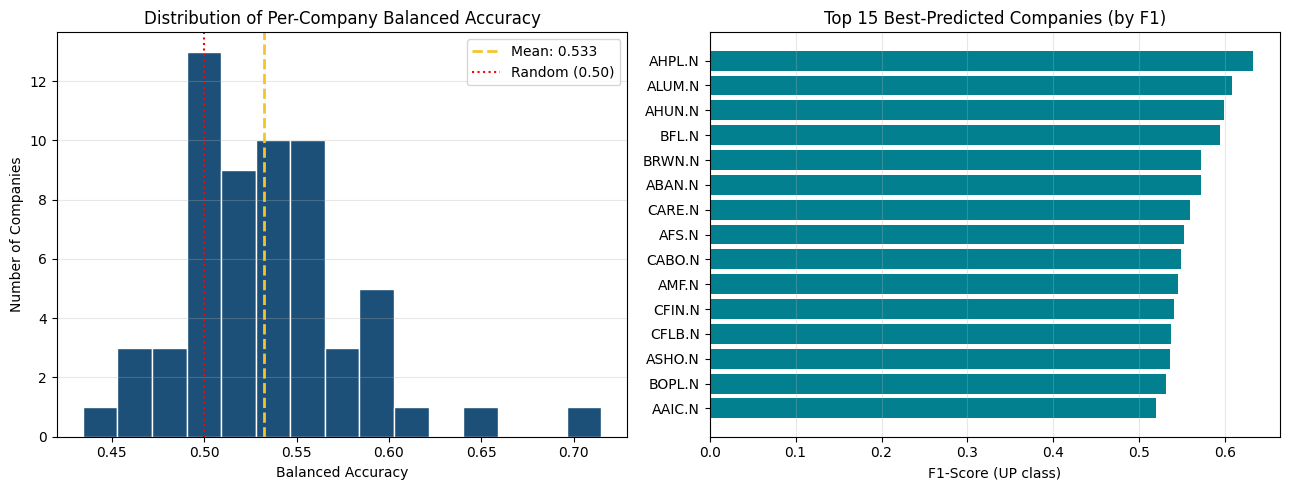

Saved: /content/drive/MyDrive/DMIF/models/per_company_accuracy.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of balanced accuracy across companies
axes[0].hist(company_df['balanced_accuracy'], bins=15, color='#1C5078', edgecolor='white')
axes[0].axvline(company_df['balanced_accuracy'].mean(), color='#F4C430', linestyle='--', linewidth=2, label=f"Mean: {company_df['balanced_accuracy'].mean():.3f}")
axes[0].axvline(0.5, color='red', linestyle=':', linewidth=1.5, label='Random (0.50)')
axes[0].set_xlabel('Balanced Accuracy')
axes[0].set_ylabel('Number of Companies')
axes[0].set_title('Distribution of Per-Company Balanced Accuracy')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Top 15 by F1
top15 = company_df.head(15)
axes[1].barh(top15['ticker'][::-1], top15['f1_score'][::-1], color='#028090')
axes[1].set_xlabel('F1-Score (UP class)')
axes[1].set_title('Top 15 Best-Predicted Companies (by F1)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plot_path = f'{MODELS_DIR}/per_company_accuracy.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")

# Save Per-Company Stats


In [ ]:
# Full stats JSON — keep everything for the dissertation
stats_path = f'{MODELS_DIR}/per_company_accuracy_stats.json'
with open(stats_path, 'w') as f:
    json.dump(company_df.to_dict(orient='records'), f, indent=2)
print(f"Saved: {stats_path}")

# CSV matching the Postgres company_accuracy_stats schema:
#   ticker TEXT PRIMARY KEY, test_accuracy NUMERIC, sample_count INTEGER, last_evaluated DATE
# NOTE: test_accuracy column here holds BALANCED accuracy, not raw accuracy — deliberately,
# so the web app never shows a misleadingly high number for lopsided-class stocks.
db_ready = company_df[['ticker', 'balanced_accuracy', 'sample_count', 'last_evaluated']].copy()
db_ready = db_ready.rename(columns={'balanced_accuracy': 'test_accuracy'})
csv_path = f'{MODELS_DIR}/company_accuracy_stats_for_db.csv'
db_ready.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")
print()
print("Preview (ready to import into Postgres — 'test_accuracy' column = balanced accuracy):")
print(db_ready.head(10).to_string(index=False))

print()
print("="*55)
print(f"Companies profiled       : {len(company_df)}")
print(f"Overall mean F1          : {company_df['f1_score'].mean():.4f}")
print(f"Overall mean bal. acc.   : {company_df['balanced_accuracy'].mean():.4f}")
print("="*55)

Saved: /content/drive/MyDrive/DMIF/models/per_company_accuracy_stats.json
Saved: /content/drive/MyDrive/DMIF/models/company_accuracy_stats_for_db.csv

Preview (ready to import into Postgres — 'test_accuracy' column = balanced accuracy):
ticker  test_accuracy  sample_count last_evaluated
AHPL.N       0.553180           172     2026-08-23
ALUM.N       0.548007           177     2026-08-23
AHUN.N       0.497379           178     2026-08-23
 BFL.N       0.542453           177     2026-08-23
BRWN.N       0.514278           179     2026-08-23
ABAN.N       0.644687           164     2026-08-23
CARE.N       0.549176           175     2026-08-23
 AFS.N       0.590879           112     2026-08-23
CABO.N       0.614681           144     2026-08-23
 AMF.N       0.589394           176     2026-08-23

Companies profiled       : 60
Overall mean F1          : 0.3697
Overall mean bal. acc.   : 0.5326
